# BrainHack Fall 2026: OpenScope calcium imaging — image + stimulus-triggered response

This Colab-ready notebook selects **one mesoscope two-photon Ca²⁺ imaging NWB file at random** from the OpenScope Predictive Processing project on **DANDI:001768**, streams it from DANDI (rather than downloading the whole file), plots an imaging summary image, and computes a PSTH-style **stimulus-triggered average ΔF/F response** for one ROI.

> **Terminology:** a PSTH is formally a histogram of spike times. Calcium imaging produces continuous fluorescence traces, so the analogous quantity here is a **peri-stimulus time histogram–style / peri-stimulus time course (PSTC)**: ΔF/F aligned to stimulus onset and averaged across stimulus presentations.

Project: https://allenneuraldynamics.github.io/openscope-community-predictive-processing/  
DANDI mesoscope dataset: https://dandiarchive.org/dandiset/001768  
NWB: https://www.nwb.org/


In [ ]:
# Colab setup
%pip -q install dandi pynwb h5py remfile numpy pandas matplotlib scipy


In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py, remfile
from dandi.dandiapi import DandiAPIClient
from pynwb import NWBHDF5IO

# Reproducible random choice: change this seed to pick a different Ca-imaging NWB.
RANDOM_SEED = 2026
DANDISET_ID = "001768"      # OpenScope mesoscope two-photon Ca2+ imaging
DANDISET_VERSION = "draft" # current public draft
random.seed(RANDOM_SEED)


## 1. Choose a calcium-imaging NWB at random

We query DANDI for NWB assets in Dandiset 001768 and select one using a fixed random seed. The selected asset path is printed so the analysis is reproducible.


In [ ]:
client = DandiAPIClient()
dandiset = client.get_dandiset(DANDISET_ID, version_id=DANDISET_VERSION)
assets = [a for a in dandiset.get_assets() if a.path.endswith(".nwb")]
if not assets:
    raise RuntimeError("No .nwb assets found in DANDI:001768 draft.")

asset = random.choice(assets)
print(f"Found {len(assets)} NWB assets")
print("Randomly selected asset:", asset.path)
print("Asset size (bytes):", getattr(asset, "size", "unknown"))
url = asset.get_content_url(follow_redirects=1, strip_query=True)


Found 86 NWB assets
Randomly selected asset: sub-837568/sub-837568_ses-multiplane-ophys-837568-2026-02-24-11-35-15_ophys.nwb
Asset size (bytes): 4302058917


## 2. Stream the NWB from DANDI

The official project data-release documentation demonstrates HTTP range-request streaming with `remfile` + `h5py`. This avoids downloading an entire potentially large NWB file.


In [ ]:
remote_file = remfile.File(url)
h5 = h5py.File(remote_file, mode="r")
io = NWBHDF5IO(file=h5, mode="r", load_namespaces=True)
nwb = io.read()

print("Session:", nwb.session_id or nwb.identifier)
print("Start:", nwb.session_start_time)
print("Subject:", getattr(nwb.subject, "subject_id", None))
print("Processing modules:", list(nwb.processing.keys()))
print("Interval tables:", list(nwb.intervals.keys()))


/usr/local/lib/python3.13/dist-packages/hdmf/spec/catalog.py:101: UserWarning: ndx-events.extensions defines a different specification for TimestampVectorData than the existing definition from nwb.event.yaml. Defaulting to the existing specification from nwb.event.yaml, but compatibility issues may be present. Please update the extension version if possible.
  self.register_spec(spec, source_file)
/usr/local/lib/python3.13/dist-packages/hdmf/spec/catalog.py:101: UserWarning: ndx-events.extensions defines a different specification for DurationVectorData than the existing definition from nwb.event.yaml. Defaulting to the existing specification from nwb.event.yaml, but compatibility issues may be present. Please update the extension version if possible.
  self.register_spec(spec, source_file)
/usr/local/lib/python3.13/dist-packages/hdmf/spec/catalog.py:101: UserWarning: ndx-events.extensions defines a different specification for MeaningsTable than the existing definition from table.yaml. 

Session: multiplane-ophys_837568_2026-02-24_11-35-15
Start: 2026-02-24 11:35:15.167924-08:00
Subject: 837568
Processing modules: ['VISl_4', 'VISl_5', 'VISl_6', 'VISl_7', 'VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'eye_tracking', 'running', 'stimulus']
Interval tables: ['Control block 1_presentations', 'Control block 2_presentations', 'Control block 3_presentations', 'Control block 4_presentations', 'RF mapping_presentations', 'Sensory-motor mismatch block_presentations', 'Zebra_presentations', 'spontaneous_presentations']


## 3. Find an imaging plane with ΔF/F and a summary image

Mesoscope NWBs organize data by imaging plane. Object names can vary slightly across sessions, so the code searches each processing module rather than hard-coding a particular VISp/VISl plane.


In [ ]:
def find_plane_module(nwb):
    candidates = []
    for name, module in nwb.processing.items():
        keys = list(module.data_interfaces.keys())
        low = [k.lower() for k in keys]
        has_dff = any("dff" in k for k in low)
        has_img = any("image" in k for k in low)
        if has_dff:
            candidates.append((name, module, keys, has_img))
    if not candidates:
        raise RuntimeError("Could not find a processing module containing a dF/F interface.")
    # Prefer one that also contains an image interface.
    candidates.sort(key=lambda x: x[3], reverse=True)
    return candidates[0]

plane_name, plane, plane_keys, _ = find_plane_module(nwb)
print("Selected plane:", plane_name)
print("Interfaces:", plane_keys)


Selected plane: VISl_4
Interfaces: ['dff_timeseries', 'event_timeseries', 'image_segmentation', 'images', 'neuropil_corrected_timeseries', 'neuropil_fluorescence_timeseries', 'raw_timeseries']


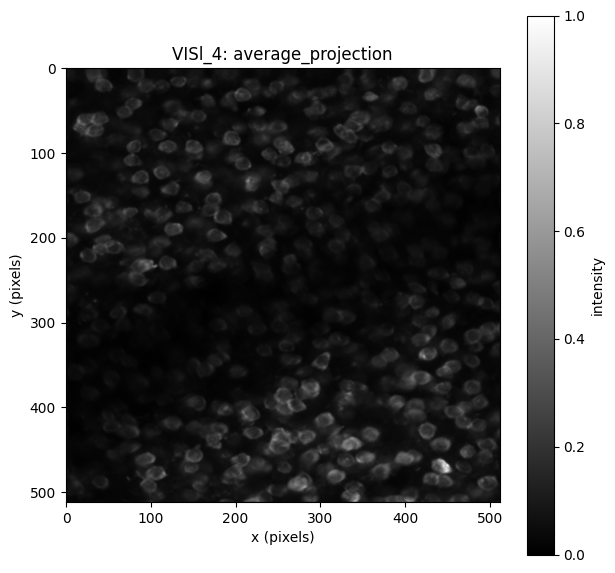

In [ ]:
# Find and display a representative image from the selected plane.
def get_first_image(interface):
    # NWB Images container
    if hasattr(interface, "images"):
        imgs = interface.images
        names = list(imgs.keys())
        if names:
            obj = imgs[names[0]]
            return names[0], np.asarray(obj.data[:])
    # ImageSeries-like object
    if hasattr(interface, "data"):
        arr = np.asarray(interface.data[:])
        if arr.ndim >= 2:
            return getattr(interface, "name", "image"), arr
    return None, None

image_name = image_data = None
for key, interface in plane.data_interfaces.items():
    if "image" in key.lower():
        image_name, image_data = get_first_image(interface)
        if image_data is not None:
            break

if image_data is None:
    raise RuntimeError("No summary image was found in the selected plane.")

image_data = np.squeeze(image_data)
if image_data.ndim > 2:
    image_data = image_data[0]

plt.figure(figsize=(7, 7))
plt.imshow(image_data, cmap="gray")
plt.title(f"{plane_name}: {image_name}")
plt.xlabel("x (pixels)")
plt.ylabel("y (pixels)")
plt.colorbar(label="intensity")
plt.show()


## 4. Locate ΔF/F traces

The next cell searches the plane for a `RoiResponseSeries`-like ΔF/F object. It then chooses an ROI with finite variance so that the example is activity-bearing rather than a flat/invalid trace.


In [ ]:
def find_dff_series(module):
    for key, interface in module.data_interfaces.items():
        if "dff" not in key.lower():
            continue
        # Direct TimeSeries/RoiResponseSeries
        if hasattr(interface, "data"):
            return interface
        # Fluorescence container
        if hasattr(interface, "roi_response_series"):
            series = interface.roi_response_series
            if len(series):
                return series[list(series.keys())[0]]
    # second pass: containers whose children contain dff
    for key, interface in module.data_interfaces.items():
        if hasattr(interface, "roi_response_series"):
            for sname, series in interface.roi_response_series.items():
                if "dff" in sname.lower():
                    return series
    raise RuntimeError("Could not locate a dF/F response series.")

dff = find_dff_series(plane)
print("dF/F series:", dff.name)
print("shape:", dff.data.shape)

# NWB convention is usually time x ROI; handle either orientation.
shape = dff.data.shape
if len(shape) != 2:
    raise RuntimeError(f"Expected 2-D dF/F data, got shape {shape}")

time_axis = 0 if shape[0] >= shape[1] else 1
n_time = shape[time_axis]
n_roi = shape[1-time_axis]

# Load a small time slice to choose an ROI without pulling the full matrix.
probe_n = min(n_time, 5000)
probe = np.asarray(dff.data[:probe_n, :]) if time_axis == 0 else np.asarray(dff.data[:, :probe_n]).T
variances = np.nanvar(probe, axis=0)
roi_idx = int(np.nanargmax(variances))
trace = np.asarray(dff.data[:, roi_idx]) if time_axis == 0 else np.asarray(dff.data[roi_idx, :])

if dff.timestamps is not None:
    timestamps = np.asarray(dff.timestamps[:])
else:
    timestamps = dff.starting_time + np.arange(n_time) / float(dff.rate)

print(f"Using ROI {roi_idx} of {n_roi}")
print(f"Trace duration: {timestamps[0]:.2f} to {timestamps[-1]:.2f} s")


dF/F series: dff_timeseries
shape: (41008, 359)
Using ROI 355 of 359
Trace duration: 42.95 to 4368.56 s


## 5. Find stimulus onset times

The project stores synchronized visual stimulus presentations in NWB `TimeIntervals` tables. We select a table with multiple stimulus presentations and use its `start_time` column as event onset.


In [ ]:
stim_candidates = []
for name, table in nwb.intervals.items():
    lname = name.lower()
    if "present" in lname and "spontaneous" not in lname:
        try:
            df = table.to_dataframe()
            if "start_time" in df.columns and len(df) >= 5:
                stim_candidates.append((name, df))
        except Exception:
            pass

if not stim_candidates:
    raise RuntimeError("No suitable stimulus-presentation interval table found.")

# Prefer an orientation/oddball table if present, otherwise use the largest presentation table.
def stim_score(item):
    name, df = item
    bonus = 100000 if any(x in name.lower() for x in ["orientation", "oddball"]) else 0
    return bonus + len(df)

stim_name, stim = max(stim_candidates, key=stim_score)
print("Stimulus table:", stim_name)
print("Rows:", len(stim))
display(stim.head())

onsets = stim["start_time"].to_numpy(dtype=float)
# Keep only events that have room for the full peri-stimulus window.
PRE, POST = 1.0, 2.0
onsets = onsets[(onsets >= timestamps[0] + PRE) & (onsets <= timestamps[-1] - POST)]
print("Usable stimulus onsets:", len(onsets))


Stimulus table: Sensory-motor mismatch block_presentations
Rows: 45461


,start_time,stop_time,stim_name,stim_type,stim_block,Orientation,SpatialFrequency,TemporalFrequency,contrast,phase,...,Delay,BlockNumber,BlockLabel,TrialNumber,SequenceNumber,TrialInSequence,TrialType,BlockType,stim_index,timeseries
id,,,,,,,,,,,,,,,,,,,,,
0,423.39913,423.43246,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,-1.730026364326477,...,0.0,2.0,Sensory-motor mismatch block,545.0,0.0,0.0,standard,motor_oddball,0.0,"[(544, 1, timestamps pynwb.base.TimeSeries at ..."
1,423.43246,423.46585,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,-1.730026364326477,...,0.0,2.0,Sensory-motor mismatch block,546.0,0.0,0.0,standard,motor_oddball,0.0,"[(545, 1, timestamps pynwb.base.TimeSeries at ..."
2,423.46585,423.49922,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,-1.730026364326477,...,0.0,2.0,Sensory-motor mismatch block,547.0,0.0,0.0,standard,motor_oddball,0.0,"[(546, 1, timestamps pynwb.base.TimeSeries at ..."
3,423.49922,423.53255,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,-1.730026364326477,...,0.0,2.0,Sensory-motor mismatch block,548.0,0.0,0.0,standard,motor_oddball,0.0,"[(547, 1, timestamps pynwb.base.TimeSeries at ..."
4,423.53255,423.56595,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,-1.730026364326477,...,0.0,2.0,Sensory-motor mismatch block,549.0,0.0,0.0,standard,motor_oddball,0.0,"[(548, 1, timestamps pynwb.base.TimeSeries at ..."


Usable stimulus onsets: 45461


## 6. Stimulus-triggered calcium response (PSTH-style)

For each stimulus onset we interpolate the selected ROI's ΔF/F onto a common time grid from −1 to +2 s. We baseline-subtract each trial using the pre-stimulus interval (−1 to 0 s), then plot the mean ± SEM. This is the calcium-imaging analogue of a spike PSTH.


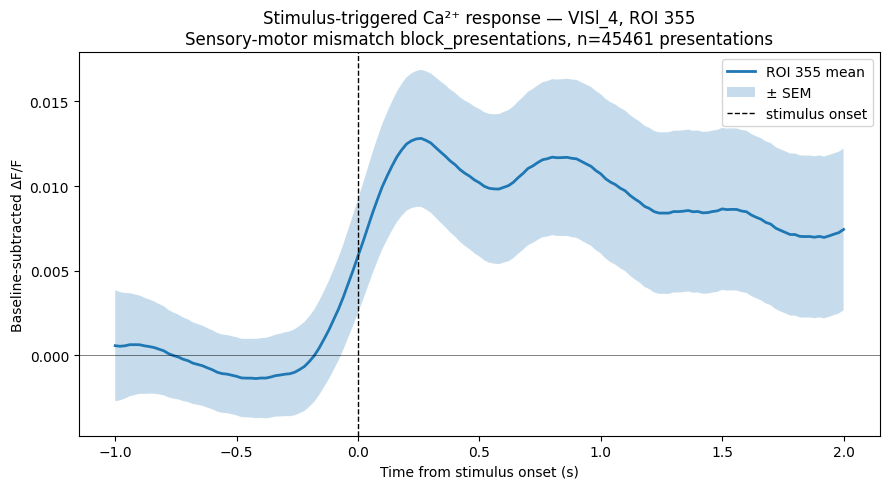

In [ ]:
from scipy.interpolate import interp1d

# 20 ms bins are adequate for a compact visualization; interpolation uses native timestamps.
rel_t = np.arange(-PRE, POST + 1e-9, 0.02)
interp = interp1d(timestamps, trace, kind="linear", bounds_error=False, fill_value=np.nan)
trials = np.vstack([interp(t0 + rel_t) for t0 in onsets])

baseline_mask = (rel_t >= -PRE) & (rel_t < 0)
baseline = np.nanmean(trials[:, baseline_mask], axis=1, keepdims=True)
trials_bs = trials - baseline

mean_resp = np.nanmean(trials_bs, axis=0)
n_eff = np.sum(np.isfinite(trials_bs), axis=0)
sem_resp = np.nanstd(trials_bs, axis=0, ddof=1) / np.sqrt(np.maximum(n_eff, 1))

plt.figure(figsize=(9, 5))
plt.plot(rel_t, mean_resp, lw=2, label=f"ROI {roi_idx} mean")
plt.fill_between(rel_t, mean_resp-sem_resp, mean_resp+sem_resp, alpha=0.25, label="± SEM")
plt.axvline(0, linestyle="--", linewidth=1, color="black", label="stimulus onset")
plt.axhline(0, linewidth=0.7, color="black", alpha=0.5)
plt.xlabel("Time from stimulus onset (s)")
plt.ylabel("Baseline-subtracted ΔF/F")
plt.title(f"Stimulus-triggered Ca²⁺ response — {plane_name}, ROI {roi_idx}\n{stim_name}, n={len(onsets)} presentations")
plt.legend()
plt.tight_layout()
plt.show()


## Interpretation

- **Image:** the first figure is a stored summary/projection image for the randomly selected imaging plane, giving anatomical/spatial context for the extracted ROIs.
- **Stimulus-triggered response:** the second figure asks whether the selected ROI shows a systematic fluorescence change around stimulus onset. A positive deflection after time 0 indicates an average increase in calcium-related fluorescence relative to the pre-stimulus baseline.
- **Important:** pooling every presentation in a table is a simple first-pass analysis. For predictive-processing questions, the next step is to split trials by experimental condition (for example standard vs oddball/mismatch vs omission), match controls, and compare their stimulus-triggered responses.

### Provenance

This notebook uses the OpenScope Predictive Processing project's **mesoscope two-photon Ca²⁺ imaging Dandiset 001768**. The project data-release documentation identifies DANDI:001768 as the mesoscope dataset and describes per-plane NWB objects containing ROI masks, ΔF/F traces, inferred events, and projection images. The notebook intentionally discovers object names at runtime because names can vary slightly among sessions.

Sources:
- OpenScope project: https://allenneuraldynamics.github.io/openscope-community-predictive-processing/
- Data release / NWB map: https://allenneuraldynamics.github.io/openscope_p3_data_release_paper/
- DANDI:001768: https://dandiarchive.org/dandiset/001768
- NWB: https://www.nwb.org/


In [ ]:
io.close()
h5.close()
remote_file.close()
print("Done.")

Done.
